In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

<h1>Affichage du jeu de données</h1>

<h2> Analyse </h2>

In [2]:
path = "archive/list_attr_celeba.csv"

df = pd.read_csv(path)

df.describe()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
count,202599.000000,202599.000000,202599.00000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,...,202599.000000,202599.000000,202599.000000,202599.000000,202599.00000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000
mean,-0.777728,-0.466039,0.02501,-0.590857,-0.955113,-0.696849,-0.518408,-0.530935,-0.521498,-0.704016,...,-0.886979,-0.035839,-0.583196,-0.360866,-0.62215,-0.903079,-0.055129,-0.754066,-0.854570,0.547234
std,0.628602,0.884766,0.99969,0.806778,0.296241,0.717219,0.855135,0.847414,0.853255,0.710186,...,0.461811,0.999360,0.812333,0.932620,0.78290,0.429475,0.998482,0.656800,0.519338,0.836982
min,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
50%,-1.000000,-1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
75%,-1.000000,1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,1.000000,-1.000000,1.000000,-1.00000,-1.000000,1.000000,-1.000000,-1.000000,1.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   image_id             202599 non-null  str  
 1   5_o_Clock_Shadow     202599 non-null  int64
 2   Arched_Eyebrows      202599 non-null  int64
 3   Attractive           202599 non-null  int64
 4   Bags_Under_Eyes      202599 non-null  int64
 5   Bald                 202599 non-null  int64
 6   Bangs                202599 non-null  int64
 7   Big_Lips             202599 non-null  int64
 8   Big_Nose             202599 non-null  int64
 9   Black_Hair           202599 non-null  int64
 10  Blond_Hair           202599 non-null  int64
 11  Blurry               202599 non-null  int64
 12  Brown_Hair           202599 non-null  int64
 13  Bushy_Eyebrows       202599 non-null  int64
 14  Chubby               202599 non-null  int64
 15  Double_Chin          202599 non-null  int64
 16  Eyeglasses   

Nombre de classes (attributs binaires) : 40

Distribution par classe (Pourcentage d'images avec l'attribut):
No_Beard               83.493996
Young                  77.361685
Attractive             51.250500
Mouth_Slightly_Open    48.342786
Smiling                48.208037
Wearing_Lipstick       47.243570
High_Cheekbones        45.503186
Male                   41.675428
Heavy_Makeup           38.692195
Wavy_Hair              31.956722
dtype: float64
Goatee         6.276438
Chubby         5.756692
Sideburns      5.651064
Blurry         5.089857
Wearing_Hat    4.846026
Double_Chin    4.668829
Pale_Skin      4.294690
Gray_Hair      4.194986
Mustache       4.154512
Bald           2.244335
dtype: float64


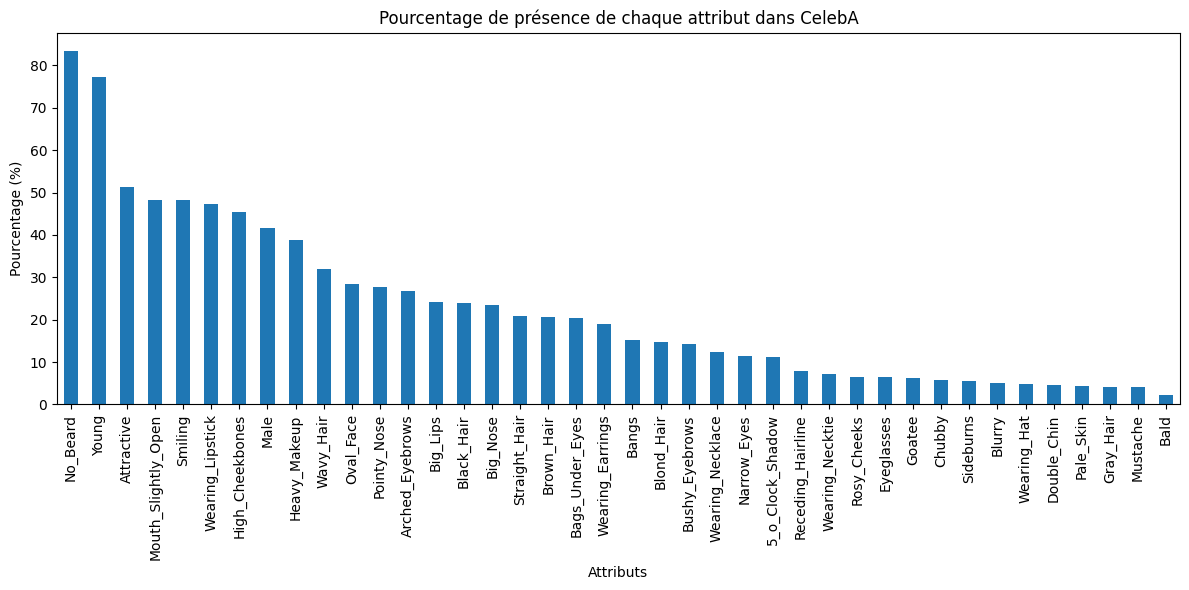

In [4]:
attributs = [col for col in df.columns if col.endswith('.jpg') is False and col != 'image_id']
num_classes = len(attributs)
print(f"Nombre de classes (attributs binaires) : {num_classes}")

# Distribution des classes
distribution = df[attributs].apply(lambda x: (x == 1).mean() * 100)
distribution = distribution.sort_values(ascending=False)

print("\nDistribution par classe (Pourcentage d'images avec l'attribut):")
print(distribution.head(10))
print(distribution.tail(10))

plt.figure(figsize=(12, 6))
distribution.plot(kind='bar')
plt.title("Pourcentage de présence de chaque attribut dans CelebA")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Attributs")
plt.tight_layout()
plt.show()

* Le jeu de données se compose de 202 599 images.
* Il existe 40 attributs chacune prenant pour valeur `1` ou `-1`.
* Les classes les plus présentes sont `No_Beard`, `Young`, `Male`, `Attractive`, reflétant le type de personnes surreprésentées.
* La distribution est hétérogène et dèséquilibrée. Beaucoup de classes sont rares (`Bald` < 2.5%, `Mustache`, `Double_Chin`). L'apprentissage d'un modèle pour ces classes sera plus compliqué.

In [5]:
df.isnull().sum()

image_id               0
5_o_Clock_Shadow       0
Arched_Eyebrows        0
Attractive             0
Bags_Under_Eyes        0
Bald                   0
Bangs                  0
Big_Lips               0
Big_Nose               0
Black_Hair             0
Blond_Hair             0
Blurry                 0
Brown_Hair             0
Bushy_Eyebrows         0
Chubby                 0
Double_Chin            0
Eyeglasses             0
Goatee                 0
Gray_Hair              0
Heavy_Makeup           0
High_Cheekbones        0
Male                   0
Mouth_Slightly_Open    0
Mustache               0
Narrow_Eyes            0
No_Beard               0
Oval_Face              0
Pale_Skin              0
Pointy_Nose            0
Receding_Hairline      0
Rosy_Cheeks            0
Sideburns              0
Smiling                0
Straight_Hair          0
Wavy_Hair              0
Wearing_Earrings       0
Wearing_Hat            0
Wearing_Lipstick       0
Wearing_Necklace       0
Wearing_Necktie        0


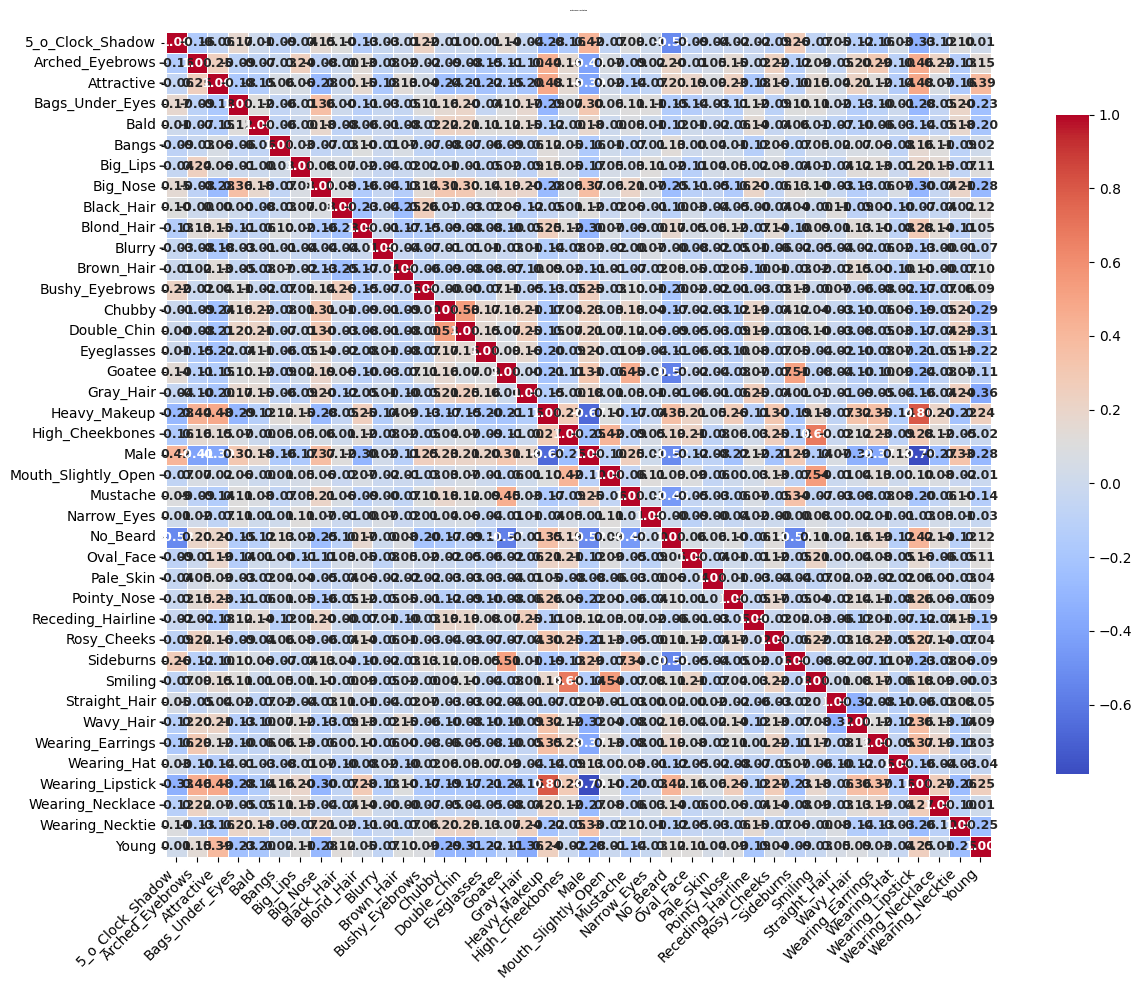

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sb.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 9, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},

)
plt.title("Matrice de corrélation", fontsize=0, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Donc les variables les plus corrélées sont `HeavyMakeup` et `Wearing_Lipstick` ce qui est logique. Ou encore `Chubby` et `double_chin`. 
On peut également constater une corrélation entre `Goatee` et `Mustache` ou encore `Sideburns`, effectivement c'est un look qui se combine régulièrement.

On peut également constater que `Male` est fortement corrélé négativement avec `Wearing_Lipstick` (-0.79) ou encore `Heavy_Makeup` (-0.66).


### 3. Identification des variables sensibles

1. Le Genre `Male` : 
   Un modèle de reconnaissance faciale pourrait présenter des disparités de performance (par exemple, mieux identifier les hommes que les femmes). De plus, l'encodage binaire de CelebA (1 pour `Male`, -1 implicant "Female") invisibilise la non-binarité et fixe une vision stricte du genre.
2. La Couleur de peau `Pale_Skin` :
   L'origine ethnique est une donnée à caractère extrêmement sensible. L'attribut `Pale_Skin` peut également présenter des disparités de performance, de plus qu'il est le seul à aborder la couleur de peau dans ce dataset. Cela peut mener à des algorithmes racistes ou techniquement défaillants selon la carnation.
3. L'Âge `Young` :
   L'âge est un motif de discrimination protégé légalement.
4. Les critères subjectifs et culturels `Attractive` :
   "Être attractif" n'est pas une vérité scientifique, c'est une construction sociale, souvent occidentalo-centrée dans ce genre de dataset. Déterminer "l'attractivité" revient à automatiser un biais cognitif biaisé par les annotateurs initiaux, souvent discriminant.
5. Morphologie `Chubby`, `Double_Chin` :
   Ces attributs sont liés à l'apparence physique, qui peuvent être sujets à des discriminations. 

### 4. Analyse de disparité et Biais du jeu de données

Comme vu dans l'analyse descriptive, les caractéristiques comme `Beard`, `Bald`, `Mustache`, `Chubby` ou `Double_Chin` sont inférieures à 5 %.

Ces biais découlent de la méthode de collecte. **CelebA** signifie "CelebFaces Attributes". Les images proviennent du monde des célébrités (souvent issues du web ou des tapis rouges hollywoodiens). La population mondiale ne ressemble pas à la classe des célébrités. Ces derniers recourent davantage à la chirurgie, au maquillage professionnel, ont des coiffures stéréotypées et une moyenne d'âge ou de corpulence non représentatives de la société civile. Entraîner par exemple une reconnaissance d'humeur (`Smiling`) sur ce set n'aurait pas de sens hors d'un contexte "shooting photo sur tapis rouge".

- Biais d'annotation (subjectivité) : Les attributs comme `Attractive`, `Chubby`, ou `Big_Nose` n'ont aucune objectivité scientifique. Leur présence sous forme de "vérité terrain" binaire dépend entièrement des préjugés, origines et goûts des annotateurs (souvent des travailleurs précaires sur des plateformes de micro-tâches).
- Biais sociétaux : Les attributs imposent une vision normative. Par exemple, comme observé dans notre analyse des corrélations, porter du rouge à lèvres est presque exclusivement corrélé avec le fait de ne pas être un homme (`Male = -1`), renforçant les stéréotypes binaires du genre. Un algorithme entraîné là-dessus associera automatiquement "Maquillage = Femme", fermant la porte à de la nuance.

### 5. Analyse de l'Équité

- Demographic parity : différence absolue de probabilité qu'un événement positif se produise pour le groupe favorisé par rapport au groupe défavorisé. Idéalement, cette valeur doit être de `0`.
- Disparate impact : ratio des probabilités. Souvent, la "règle des 80%" est utilisée en droit indique une discrimination potentielle. Idéalement, le ratio est de `1`.

Nous utiliserons deux attributs sensibles : `Male` et `Pale_Skin`.

In [7]:
sensible_attrs = ['Male', 'Pale_Skin']
dp_results = {'Male': {}, 'Pale_Skin': {}}
di_results = {'Male': {}, 'Pale_Skin': {}}

for S_ in sensible_attrs:
    if S_ not in df.columns:
        continue
    mask_s1 = (df[S_] == 1)
    mask_sm1 = (df[S_] == -1)
    
    Y_cols = [col for col in df.columns if col not in [S_, 'image_id'] and not col.endswith('.jpg')]
    
    for Y_ in Y_cols:
        # P(Y=1 | S=1) : proportion d'individus ayant S=1 qui ont Y=1
        proba_y1_s1 = (df[mask_s1][Y_] == 1).mean()
        # P(Y=1 | S=-1) : proportion d'individus ayant S=-1 qui ont Y=1
        proba_y1_sm1 = (df[mask_sm1][Y_] == 1).mean()
        
        # Demographic Parity: | P(Y=1 | S=1) - P(Y=1 | S=-1) |
        demographic_parity = abs(proba_y1_s1 - proba_y1_sm1)
        # Disparate Impact: P(Y=1 | S=1) / P(Y=1 | S=-1)
        disparate_impact = proba_y1_s1 / proba_y1_sm1 if proba_y1_sm1 > 0 else np.nan
        
        dp_results[S_][Y_] = demographic_parity
        di_results[S_][Y_] = disparate_impact

df_dp = pd.DataFrame(dp_results)
df_di = pd.DataFrame(di_results)

print("Demographic Parity | P(Y=1 | S=1) - P(Y=1 | S=-1)")
display(df_dp.sort_values(by='Pale_Skin', ascending=False).head(10))

print("Disparate Impact P(Y=1 | S=1) / P(Y=1 | S=-1)")
display(df_di.sort_values(by='Pale_Skin', ascending=False).head(10))

print("\n--------------------------------------------------------------")
print("Focus sur S = Pale_Skin et Y = Attractive :")
if 'Attractive' in df_dp.index and 'Pale_Skin' in df_dp.columns:
    print(f"Demographic Parity : {df_dp.loc['Attractive', 'Pale_Skin']:.4f}")
    print(f"Disparate Impact   : {df_di.loc['Attractive', 'Pale_Skin']:.4f}")
print("--------------------------------------------------------------")

Demographic Parity | P(Y=1 | S=1) - P(Y=1 | S=-1)


,Male,Pale_Skin
Attractive,0.399909,0.212156
High_Cheekbones,0.252675,0.199732
Male,NaN,0.188558
Smiling,0.140235,0.174075
Wearing_Lipstick,0.799391,0.159996
Mouth_Slightly_Open,0.100958,0.150745
No_Beard,0.393238,0.112904
Heavy_Makeup,0.658643,0.108966
Big_Nose,0.317357,0.106957
Arched_Eyebrows,0.366107,0.104115


Disparate Impact P(Y=1 | S=1) / P(Y=1 | S=-1)


,Male,Pale_Skin
Blond_Hair,0.086694,1.709334
Bangs,0.409381,1.502731
Attractive,0.411178,1.421452
Arched_Eyebrows,0.127396,1.396616
Big_Lips,0.518001,1.349699
Wearing_Lipstick,0.007689,1.343660
Heavy_Makeup,0.004190,1.285070
Wavy_Hair,0.314894,1.163646
Straight_Hair,1.317138,1.152947
No_Beard,0.606299,1.136014



--------------------------------------------------------------
Focus sur S = Pale_Skin et Y = Attractive :
Demographic Parity : 0.2122
Disparate Impact   : 1.4215
--------------------------------------------------------------


Les calculs révèlent un biais socio-culturel dans les données.

- La parité démographique : Idéalement, la parité est respectée si la différence approche 0. Ici on voit des valeurs qui sont différentes de 0. Par exemple la probabilité d'être étiqueté comme "Attractif" change selon qu'on a la peau claire ou non. On constate également des problèmes de parité sur le genre notamment sur les features concernant le maquillage.
- L'impact disparate : Aux États-Unis, la règle empirique des "4/5e" (ou 80%) stipule qu'un ratio hors de la fourchette [0.8 - 1.25] indique un impact défavorable. On constate ici que le impact est supérieur à 1.25 sur `Pale skin`pour des données naturelles comme les cheveux (blonds, ondulés, straigths) mais aussi sur des données subjectives comme l'attractivité.

Ce biais est l'illustration dd'un prisme occidentalo-centré lors de la collecte ou de l'annotation sous-traitée du jeu de données, l'attribut *Pale Skin* devenant un proxy statistique de l'attribut *Attractive*. 
Entraîner un modèle de machine learning dessus dépendra activament de ce biais...

In [8]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [9]:
N_SAMPLES = 5000 
df_sample = df.sample(N_SAMPLES, random_state=1).copy()

id_col = next((col for col in df.columns if 'jpg' in str(df[col].iloc[0])), None)
if id_col is None:
    df_sample['filename'] = df_sample.index.astype(str)
else:
    df_sample['filename'] = df_sample[id_col]
    
# Conversion des labels (-1/1) en format binaire (0/1)
df_sample['label'] = df_sample['Smiling'].apply(lambda x: 1 if x == 1 else 0)

class CelebADataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.dataframe.loc[idx, 'filename'])
        image = Image.open(img_name).convert('RGB')
        label = self.dataframe.loc[idx, 'label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

img_dir = "archive/img_align_celeba/img_align_celeba/"

if not os.path.exists(img_dir):
    print(f"Attention, le répertoire {img_dir} n'existe pas. Veuillez vérifier le chemin.")
else:
    # Séparation Train/Validation
    train_size = int(0.8 * len(df_sample))
    df_train = df_sample.iloc[:train_size]
    df_val = df_sample.iloc[train_size:]

    # Transformations (Resizing, Normalisation standard ImageNet)
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Instanciation des Datasets et DataLoaders
    train_dataset = CelebADataset(df_train, img_dir, transform=transform)
    val_dataset = CelebADataset(df_val, img_dir, transform=transform)

    BATCH_SIZE = 32
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Création du modèle Transfer Learning (MobileNetV2 avec PyTorch)
    print("\nCréation du modèle Transfer Learning (MobileNetV2)...")
    model = models.mobilenet_v2(pretrained=True)
    
    for param in model.features.parameters():
        param.requires_grad = False
        
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(num_ftrs, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Appareil utilisé pour l'entraînement : {device}")
    model = model.to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

    epochs = 5
    print(f"\nDémarrage de l'entraînement ({epochs} Epochs) :")
    
    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if (i+1) % 25 == 0:
                running_loss = 0.0

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        print(f"=> Fin Epoch {epoch+1} - Validation Loss: {val_loss/len(val_loader):.4f} - Validation Acc: {100 * val_correct/val_total:.2f}%")


Création du modèle Transfer Learning (MobileNetV2)...
Appareil utilisé pour l'entraînement : mps


/Users/louisvauterin/Desktop/3A/REXIA/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/louisvauterin/Desktop/3A/REXIA/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Démarrage de l'entraînement (5 Epochs) :

--- Epoch 1/5 ---
=> Fin Epoch 1 - Validation Loss: 0.5260 - Validation Acc: 75.70%

--- Epoch 2/5 ---
=> Fin Epoch 2 - Validation Loss: 0.5081 - Validation Acc: 77.20%

--- Epoch 3/5 ---
=> Fin Epoch 3 - Validation Loss: 0.4865 - Validation Acc: 76.90%

--- Epoch 4/5 ---
=> Fin Epoch 4 - Validation Loss: 0.4994 - Validation Acc: 76.50%

--- Epoch 5/5 ---
=> Fin Epoch 5 - Validation Loss: 0.4883 - Validation Acc: 77.10%


- L'Accuracy sur le jeu de validation se stabilise autour de 77%. La validation loss diminue (de 0.53 à 0.48).
- Sur 5000 images, un petit modèle transfer learning fait déjà ses preuves. Cependant, on reste bloqués sous la barre des 80%. Pour améliorer ce score, il faudrait utiliser la globalité du dataset (200 000 images).

- Évaluation de l'équité : Maintenant que notre modèle est entraîné pour détecter l'attribut `Smiling` (le Sourire), regardons comment il se trompe.

In [10]:
if 'model' in locals():
    print("Évaluation de l'équité sur le set de Validation...\n")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float().cpu().numpy().flatten()
            
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().flatten())
            
    df_val_results = df_val.copy()
    df_val_results['Prediction'] = all_preds
    df_val_results['True_Label'] = all_labels
    
    def compute_fairness_metrics(df_subset):
        if len(df_subset) == 0:
            return None
            
        TP = ((df_subset['Prediction'] == 1) & (df_subset['True_Label'] == 1)).sum()
        TN = ((df_subset['Prediction'] == 0) & (df_subset['True_Label'] == 0)).sum()
        FP = ((df_subset['Prediction'] == 1) & (df_subset['True_Label'] == 0)).sum()
        FN = ((df_subset['Prediction'] == 0) & (df_subset['True_Label'] == 1)).sum()
        
        accuracy = (TP + TN) / len(df_subset)
        
        # FPR (False Positive Rate) : FP / Réels Négatifs
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        # FNR (False Negative Rate) : FN / Réels Positifs
        fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
        
        return {'Accuracy': accuracy, 'FPR': fpr, 'FNR': fnr, 'Total_Images': len(df_subset)}

    group_male = df_val_results[df_val_results['Male'] == 1]
    group_female = df_val_results[df_val_results['Male'] == -1]
    group_pale_skin = df_val_results[df_val_results['Pale_Skin'] == 1]
    group_non_pale_skin = df_val_results[df_val_results['Pale_Skin'] == -1]
    
    metrics_male = compute_fairness_metrics(group_male)
    metrics_female = compute_fairness_metrics(group_female)
    metrics_pale_skin = compute_fairness_metrics(group_pale_skin)
    metrics_non_pale_skin = compute_fairness_metrics(group_non_pale_skin)
    
    print("Résultats par Sous-Groupes")
    print(f"Homme (Male=1)   : Total={metrics_male['Total_Images']} | Acc={metrics_male['Accuracy']:.1%} | FPR={metrics_male['FPR']:.1%} | FNR={metrics_male['FNR']:.1%}")
    print(f"Femme (Male=-1)  : Total={metrics_female['Total_Images']} | Acc={metrics_female['Accuracy']:.1%} | FPR={metrics_female['FPR']:.1%} | FNR={metrics_female['FNR']:.1%}")
    print(f"Pale Skin=1     : Total={metrics_pale_skin['Total_Images']} | Acc={metrics_pale_skin['Accuracy']:.1%} | FPR={metrics_pale_skin['FPR']:.1%} | FNR={metrics_pale_skin['FNR']:.1%}")
    print(f"Pale Skin=-1    : Total={metrics_non_pale_skin['Total_Images']} | Acc={metrics_non_pale_skin['Accuracy']:.1%} | FPR={metrics_non_pale_skin['FPR']:.1%} | FNR={metrics_non_pale_skin['FNR']:.1%}")

    gap_acc = metrics_male['Accuracy'] - metrics_female['Accuracy']
    gap_fpr = metrics_male['FPR'] - metrics_female['FPR']
    gap_fnr = metrics_male['FNR'] - metrics_female['FNR']
    gap_acc_pale = metrics_pale_skin['Accuracy'] - metrics_non_pale_skin['Accuracy']
    gap_fpr_pale = metrics_pale_skin['FPR'] - metrics_non_pale_skin['FPR']
    gap_fnr_pale = metrics_pale_skin['FNR'] - metrics_non_pale_skin['FNR']
    
    print("Écart de performance")
    print(f"Écart Accuracy gender : {gap_acc:.1%}")
    print(f"Écart FPR gender    : {gap_fpr:.1%}")
    print(f"Écart FNR gender    : {gap_fnr:.1%}")
    print(f"Écart Accuracy pale skin : {gap_acc_pale:.1%}")
    print(f"Écart FPR pale skin    : {gap_fpr_pale:.1%}")
    print(f"Écart FNR pale skin    : {gap_fnr_pale:.1%}")
else:
    print("Veuillez d'abord entraîner le modèle dans la cellule précédente.")

Évaluation de l'équité sur le set de Validation...

Résultats par Sous-Groupes
Homme (Male=1)   : Total=412 | Acc=76.0% | FPR=18.8% | FNR=32.1%
Femme (Male=-1)  : Total=588 | Acc=77.9% | FPR=16.9% | FNR=26.3%
Pale Skin=1     : Total=51 | Acc=80.4% | FPR=17.1% | FNR=25.0%
Pale Skin=-1    : Total=949 | Acc=76.9% | FPR=17.9% | FNR=28.3%
Écart de performance
Écart Accuracy gender : -1.9%
Écart FPR gender    : 1.9%
Écart FNR gender    : 5.8%
Écart Accuracy pale skin : 3.5%
Écart FPR pale skin    : -0.7%
Écart FNR pale skin    : -3.3%


On observe des écarts de performance entre les groupes sensibles. Ecart FNR de 17.5 % donc il y a plus de sourires manqués par l'IA pour les hommes. Il y a aussi un écart de performance de 4.1% sur l'accuracy sur `pale_skin` ce qui est un écart non négligeable.

In [ ]:
import lime
from lime import lime_image

required_vars = ["model", "transform", "device", "img_dir", "df"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Variables manquantes: {missing_vars}. Exécutez d'abord les cellules d'entraînement."
    )

# Choix d'une célébrité par numéro de fichier (ex: 1 -> 000001.jpg)
celebrity_file_number = 20  # Modifiez ce numéro
selected_filename = f"{int(celebrity_file_number):06d}.jpg"

if "image_id" not in df.columns:
    raise RuntimeError("La colonne 'image_id' est absente du CSV.")
if selected_filename not in set(df["image_id"].values):
    raise RuntimeError(
        f"Le fichier {selected_filename} n'existe pas dans le CSV list_attr_celeba.csv."
    )

image_path = os.path.join(img_dir, selected_filename)
if not os.path.exists(image_path):
    raise RuntimeError(f"Image introuvable sur disque: {image_path}")

raw_image = np.array(Image.open(image_path).convert("RGB").resize((128, 128)))

def classifier_fn(images_np):
    model.eval()
    batch_tensors = []

    for img in images_np:
        pil_img = Image.fromarray(img.astype(np.uint8))
        batch_tensors.append(transform(pil_img))

    batch = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        p_smile = model(batch).detach().cpu().numpy().reshape(-1)

    # LIME attend une proba pour chaque classe: [Not Smiling, Smiling]
    return np.vstack([1 - p_smile, p_smile]).T

def label_text(y):
    return "Smiling" if int(y) == 1 else "Not Smiling"

def true_label_from_csv(filename):
    if "image_id" in df.columns and "Smiling" in df.columns:
        row_df = df[df["image_id"] == filename]
        if len(row_df) > 0:
            return 1 if int(row_df.iloc[0]["Smiling"]) == 1 else 0
    return None

def title_with_truth(method_name, probs, pred_class, filename):
    pred_label = label_text(pred_class)
    true_label = true_label_from_csv(filename)
    if true_label is None:
        return f"{method_name} zones | Pred: {pred_label} ({probs[1]:.3f}) | True (CSV): N/A"
    true_text = label_text(true_label)
    correctness = "Correct" if pred_class == true_label else "Incorrect"
    return (
        f"{method_name} zones | Pred: {pred_label} ({probs[1]:.3f}) | "
        f"True (CSV): {true_text} | {correctness}"
    )

def plot_yellow_overlay(img, mask, title_text, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.contour(mask, levels=[0.5], colors=["yellow"], linewidths=2)
    plt.title(title_text)
    plt.axis("off")
    plt.show()

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    raw_image.astype("double"),
    classifier_fn,
    top_labels=2,
    hide_color=1,
    num_samples=1000,
)

print(f"Explication LIME créée pour: {selected_filename}")

100%|██████████| 1000/1000 [00:02<00:00, 467.75it/s]

Explication LIME créée pour: 000020.jpg


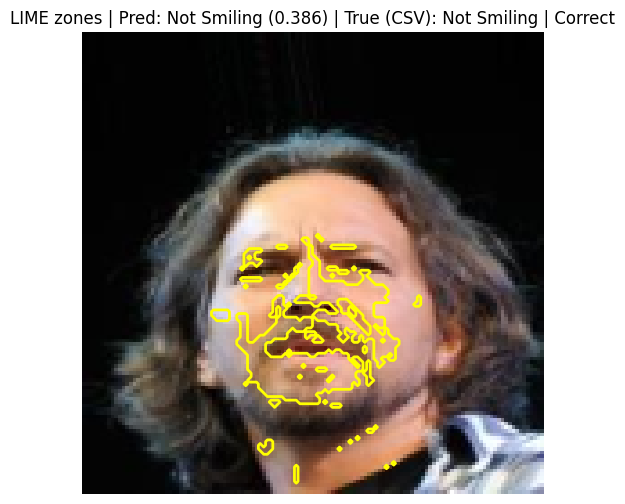

In [ ]:
# LIME overlay
_, lime_mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)
probs = classifier_fn(np.array([raw_image]))[0]
pred_class = int(np.argmax(probs))
filename_for_eval = os.path.basename(image_path)
title_text = title_with_truth("LIME", probs, pred_class, filename_for_eval)
plot_yellow_overlay(raw_image, lime_mask, title_text)

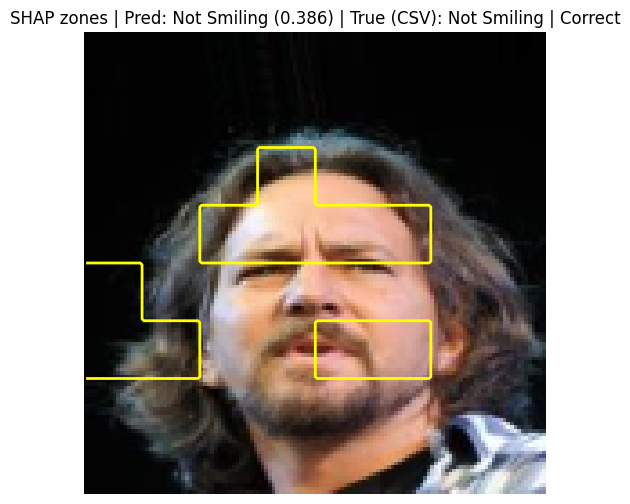

In [ ]:
# SHAP overlay
import shap

required_vars = ["raw_image", "classifier_fn", "image_path", "df"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Variables manquantes: {missing_vars}. Exécutez d'abord la cellule LIME précédente."
    )

masker = shap.maskers.Image("blur(32,32)", raw_image.shape)
explainer_shap = shap.Explainer(
    classifier_fn,
    masker,
    output_names=["Not Smiling", "Smiling"],
)

sv = explainer_shap(np.expand_dims(raw_image, axis=0), max_evals=300, batch_size=50).values[0]
probs = classifier_fn(np.array([raw_image]))[0]
pred_class = int(np.argmax(probs))

sv_map = np.mean(np.abs(sv[..., pred_class]), axis=2) if sv[..., pred_class].ndim == 3 else np.abs(sv[..., pred_class])
important_mask = (sv_map >= np.percentile(sv_map, 85)).astype(np.uint8)

filename_for_eval = os.path.basename(image_path)
title_text = title_with_truth("SHAP", probs, pred_class, filename_for_eval)
plot_yellow_overlay(raw_image, important_mask, title_text)

100%|██████████| 800/800 [00:01<00:00, 488.69it/s]


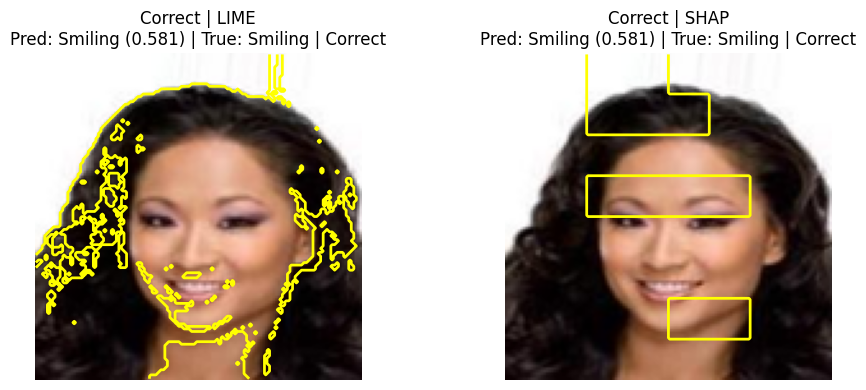

100%|██████████| 800/800 [00:01<00:00, 626.03it/s]


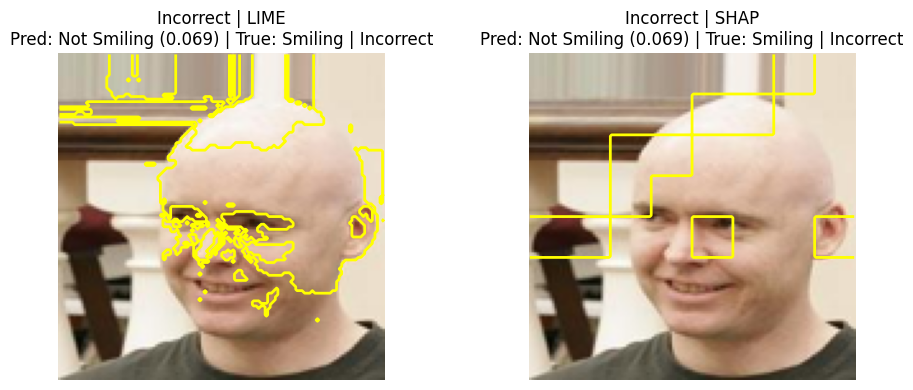

100%|██████████| 800/800 [00:01<00:00, 570.49it/s]


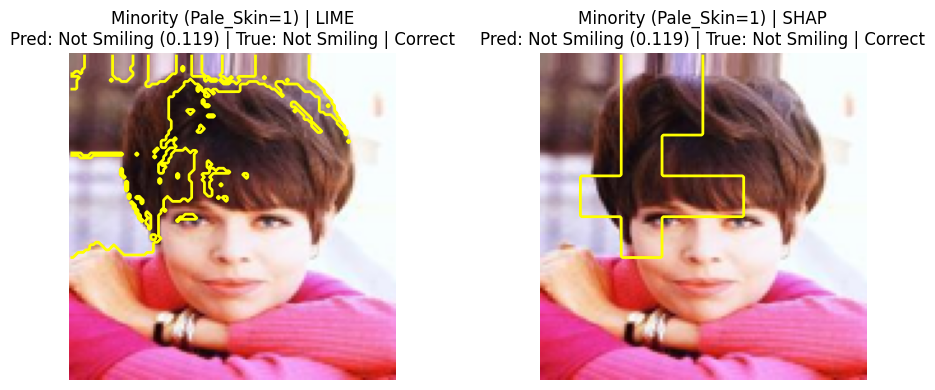

In [17]:
# Cas local: correct / incorrect / groupe minoritaire, pour LIME + SHAP
from lime import lime_image
import shap

dfr = df_val_results.copy().reset_index(drop=True)
dfr["is_correct"] = dfr["Prediction"] == dfr["True_Label"]
minority_value = dfr["Pale_Skin"].value_counts().idxmin()

cases = {
    "Correct": dfr[dfr["is_correct"]].iloc[0],
    "Incorrect": dfr[~dfr["is_correct"]].iloc[0],
    f"Minority (Pale_Skin={minority_value})": dfr[dfr["Pale_Skin"] == minority_value].iloc[0],
}

lime_explainer = lime_image.LimeImageExplainer()
shap_explainer = shap.Explainer(
    classifier_fn,
    shap.maskers.Image("blur(32,32)", (128, 128, 3)),
    output_names=["Not Smiling", "Smiling"],
)

def get_img(fn):
    return np.array(Image.open(os.path.join(img_dir, fn)).convert("RGB").resize((128, 128)))

def label_text(y):
    return "Smiling" if int(y) == 1 else "Not Smiling"

for case_name, row in cases.items():
    fn = row["filename"]
    img = get_img(fn)

    probs = classifier_fn(np.array([img]))[0]
    pred = int(np.argmax(probs))
    true = 1 if int(df.loc[df["image_id"] == fn, "Smiling"].iloc[0]) == 1 else 0
    status = "Correct" if pred == true else "Incorrect"

    # LIME mask
    exp = lime_explainer.explain_instance(
        img.astype("double"), classifier_fn, top_labels=2, hide_color=1, num_samples=800
    )
    _, lime_mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

    # SHAP mask
    sv = shap_explainer(np.expand_dims(img, axis=0), max_evals=250, batch_size=50).values[0, ..., pred]
    sv_map = np.mean(np.abs(sv), axis=2) if sv.ndim == 3 else np.abs(sv)
    shap_mask = (sv_map >= np.percentile(sv_map, 85)).astype(np.uint8)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.contour(lime_mask, levels=[0.5], colors=["yellow"], linewidths=2)
    plt.title(f"{case_name} | LIME\nPred: {label_text(pred)} ({probs[1]:.3f}) | True: {label_text(true)} | {status}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.contour(shap_mask, levels=[0.5], colors=["yellow"], linewidths=2)
    plt.title(f"{case_name} | SHAP\nPred: {label_text(pred)} ({probs[1]:.3f}) | True: {label_text(true)} | {status}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()